## Setup

In [1]:
# set libraries to refresh
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import shapely
import contextily as ctx
import xyzservices as xyz
import matplotlib.pyplot as plt

# import kml reading and set supported driver
import fiona
fiona.drvsupport.supported_drivers["KML"] = "rw"

# for TIFF files
import rasterio
from rasterio.plot import show
from rasterstats import zonal_stats
from rasterio.features import geometry_mask
from rasterio import Affine
from rasterio.enums import Resampling

# for roads
import osmnx as ox

In [3]:
from gridsample.utils import create_ids, save_shapefiles

In [4]:
ROOT_DIR = Path("../")
DATA_DIR = ROOT_DIR / "data"
RAW_DATA_DIR = DATA_DIR / "00_raw"
OUTPUT_DATA_DIR = DATA_DIR / "01_processed" / "Solar Parks" / "03 Suggested Parcels"

## Load cleaned khasras

In [5]:
# Sagar
sagar_gdf = gpd.read_parquet(OUTPUT_DATA_DIR / "Sagar" / "sagar_parcels_initial.parquet")

In [6]:
gdf = sagar_gdf

In [7]:
gdf_stripped = gdf[["parcel_id", "geometry"]].copy()

In [8]:
sagar_gdf

,parcel_id,village_name,geometry,Parcel Area (m2)
1,0,khamkuwa,"MULTIPOLYGON (((78.75289 23.57730, 78.75302 23...",7.641329e+06
4,3,mokalpur,"MULTIPOLYGON (((78.83438 23.66410, 78.83435 23...",5.056331e+06


<Axes: >

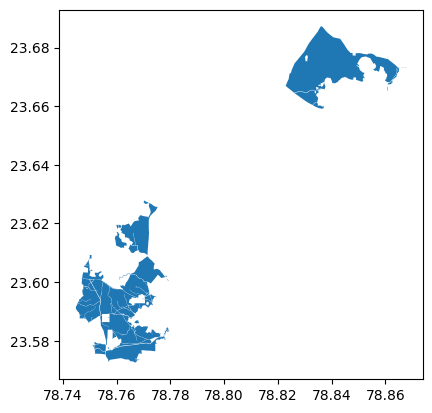

In [9]:
sagar_gdf.plot()

## External data sources

### Buildings

In [10]:
from s2cell.s2cell import lat_lon_to_cell_id
import boto3

#### Download rooftop data

Get the ID of the level 6 S2 Cell that this area sits inside

In [11]:
s2_ids = []

for index, row in gdf.iterrows():
    lat = row["geometry"].centroid.y
    lon = row["geometry"].centroid.x
    s2_cell_id = lat_lon_to_cell_id(lat=lat, lon=lon, level=6)
        
    s2_ids.append(s2_cell_id)

s2_ids = list(set(s2_ids))


Download closest S2 cell shapefile from https://beta.source.coop/vida/google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso=IND/

In [12]:
for s2_cell_id in s2_ids:
    s2_rooftops_path = RAW_DATA_DIR / "rooftops" / f"{s2_cell_id}.parquet"

    if s2_rooftops_path.exists():
        print("File already exists")
    else:
        s3 = boto3.client("s3", endpoint_url="https://data.source.coop")
        s3.download_file(
            "vida",
            f"google-microsoft-open-buildings/geoparquet/by_country_s2/country_iso=IND/{s2_cell_id}.parquet",
            str(s2_rooftops_path),
        )
        print("File downloaded.")

File already exists


#### Load and process rooftop data

In [13]:
rooftop_gdf_list = []
for s2_cell_id in s2_ids:

    s2_rooftops_path = RAW_DATA_DIR / "rooftops" / f"{s2_cell_id}.parquet"
    rooftop_gdf = gpd.read_parquet(s2_rooftops_path)
    rooftop_gdf_list.append(rooftop_gdf)

rooftop_gdf = pd.concat(rooftop_gdf_list, ignore_index=True)

In [14]:
rooftop_gdf = rooftop_gdf.drop(columns=["boundary_id", "s2_id", "geohash", "bbox", "country_iso"])

In [15]:
rooftop_gdf["rooftop_id"] = create_ids(len(rooftop_gdf), f"ROOFTOP_S2_{s2_cell_id}_")

In [16]:
rooftop_gdf

,bf_source,confidence,area_in_meters,geometry,rooftop_id
0,google,0.6912,110.4043,"POLYGON ((77.93414 22.16910, 77.93414 22.16913...",ROOFTOP_S2_4143030182204145664_0000001
1,google,0.7638,17.5882,"POLYGON ((77.93316 22.17011, 77.93316 22.17014...",ROOFTOP_S2_4143030182204145664_0000002
2,google,0.8526,98.4718,"POLYGON ((77.93666 22.16967, 77.93662 22.16977...",ROOFTOP_S2_4143030182204145664_0000003
3,google,0.7040,41.2661,"POLYGON ((77.93666 22.16986, 77.93666 22.16991...",ROOFTOP_S2_4143030182204145664_0000004
4,google,0.7426,15.9053,"POLYGON ((77.93675 22.16990, 77.93674 22.16994...",ROOFTOP_S2_4143030182204145664_0000005
...,...,...,...,...,...
1589321,google,0.7339,10.9752,"POLYGON ((79.37898 23.77614, 79.37898 23.77616...",ROOFTOP_S2_4143030182204145664_1589322
1589322,google,0.7587,29.6392,"POLYGON ((79.37900 23.77645, 79.37892 23.77647...",ROOFTOP_S2_4143030182204145664_1589323
1589323,google,0.6687,36.2318,"POLYGON ((79.37898 23.77638, 79.37899 23.77641...",ROOFTOP_S2_4143030182204145664_1589324
1589324,google,0.7223,34.7291,"POLYGON ((79.37908 23.77653, 79.37905 23.77654...",ROOFTOP_S2_4143030182204145664_1589325


#### Match rooftops to colonies

In [17]:
subset_rooftops_gdf = rooftop_gdf.sjoin(gdf_stripped, how="inner", predicate="intersects").drop(columns=["index_right"])

In [18]:
subset_rooftops_gdf

,bf_source,confidence,area_in_meters,geometry,rooftop_id,parcel_id
954956,google,0.7403,42.0995,"POLYGON ((78.74625 23.59146, 78.74625 23.59155...",ROOFTOP_S2_4143030182204145664_0954957,0
954959,google,0.6808,6.6031,"POLYGON ((78.74978 23.59372, 78.74978 23.59375...",ROOFTOP_S2_4143030182204145664_0954960,0
954960,microsoft,NaN,29.9398,"POLYGON ((78.74734 23.59483, 78.74727 23.59485...",ROOFTOP_S2_4143030182204145664_0954961,0
954961,microsoft,NaN,20.2650,"POLYGON ((78.74749 23.59485, 78.74754 23.59487...",ROOFTOP_S2_4143030182204145664_0954962,0
954962,google,0.6625,10.4498,"POLYGON ((78.74848 23.59480, 78.74848 23.59483...",ROOFTOP_S2_4143030182204145664_0954963,0
...,...,...,...,...,...,...
1499943,microsoft,NaN,56.3903,"POLYGON ((78.86310 23.67433, 78.86309 23.67427...",ROOFTOP_S2_4143030182204145664_1499944,3
1499947,google,0.7223,46.3758,"POLYGON ((78.86272 23.67460, 78.86265 23.67463...",ROOFTOP_S2_4143030182204145664_1499948,3
1499948,google,0.7692,66.0568,"POLYGON ((78.86290 23.67459, 78.86290 23.67466...",ROOFTOP_S2_4143030182204145664_1499949,3
1499949,google,0.7857,48.5043,"POLYGON ((78.86299 23.67454, 78.86298 23.67459...",ROOFTOP_S2_4143030182204145664_1499950,3


#### Produce plots and save to file

In [19]:
# for source in gdf["source"].unique():
#     folder_path = OUTPUT_DATA_DIR / source
#     folder_path.mkdir(parents=True, exist_ok=True)

#     area_rooftops = subset_rooftops_gdf[subset_rooftops_gdf["source"] == source]
#     ax = gdf[gdf["source"] == source].plot(color="orange", alpha=0.2, figsize=(10, 15))

#     # plot buildings
#     area_rooftops.plot(ax=ax)
#     # ctx.add_basemap(ax, crs=subset_rooftops_gdf.crs.to_string(), source=xyz.TileProvider.from_qms("Google Satellite Hybrid"))
#     ax.set_axis_off()
#     plt.title(f"{source} Rooftops")
    
#     plt.savefig(folder_path / "rooftops.png", bbox_inches="tight")
#     plt.close()

#     save_shapefiles(
#         area_rooftops,
#         folder_path,
#         f"raw {source} rooftops",
#         formats=["parquet", "kml"],
#     )

#     ## Get rooftop stats
#     area_rooftops["area_in_meters"].hist(bins=50)
#     plt.xlabel("Rooftop area (m2)")
#     plt.ylabel("Number of rooftops")
#     plt.title(f"{source} Rooftop Area Distribution")
#     plt.savefig(folder_path / "rooftop_area_distribution.png")
#     plt.close()

#### Pivot to get area-per-row dataset

In [20]:
rooftop_totals_df = (
    subset_rooftops_gdf.groupby("parcel_id")
    .agg(
        total_rooftop_count=("parcel_id", "size"),
        total_rooftop_area_m2=("area_in_meters", "sum"),
    )
    .reset_index()
)

# Rename the columns to have spaces
rooftop_totals_df = rooftop_totals_df.rename(
    columns={
        "total_rooftop_count": "Rooftop Count",
        "total_rooftop_area_m2": "Area Covered by Buildings (m2)",
    }
)

In [21]:
rooftop_totals_df["Area Covered by Buildings (m2)"] = rooftop_totals_df["Area Covered by Buildings (m2)"].round(1)

In [22]:
rooftop_totals_df

,parcel_id,Rooftop Count,Area Covered by Buildings (m2)
0,0,260,12672.7
1,3,241,12034.5


In [23]:
gdf_with_rooftop_stats = gdf.merge(rooftop_totals_df, on="parcel_id", how="left")

In [24]:
gdf_with_rooftop_stats[["Rooftop Count", "Area Covered by Buildings (m2)"]] = gdf_with_rooftop_stats[
    ["Rooftop Count", "Area Covered by Buildings (m2)"]
].fillna(0)
gdf_with_rooftop_stats["Rooftop Count"] = gdf_with_rooftop_stats["Rooftop Count"].astype(int)
gdf_with_rooftop_stats["Percentage Area Covered by Buildings (%)"] = (gdf_with_rooftop_stats["Area Covered by Buildings (m2)"] / gdf_with_rooftop_stats["Parcel Area (m2)"] * 100).round(2)

In [25]:
rooftop_df = gdf_with_rooftop_stats.drop(
    columns=[
        "Parcel Area (m2)",
        "geometry",
    ]
)
rooftop_df

,parcel_id,village_name,Rooftop Count,Area Covered by Buildings (m2),Percentage Area Covered by Buildings (%)
0,0,khamkuwa,260,12672.7,0.17
1,3,mokalpur,241,12034.5,0.24


### Solar datasets

In [26]:
solar_data_folderpath = (
    RAW_DATA_DIR
    / "solar_atlas"
    / "India_GISdata_LTAy_YearlyMonthlyTotals_GlobalSolarAtlas-v2_GEOTIFF"
)

In [27]:
solar_df = pd.DataFrame(index=gdf.index)

#### Averages

In [28]:
solar_irradiation_filenames = [
    "GTI.tif",
    # "DIF.tif",
    # "DNI.tif",
    "GHI.tif",
    "PVOUT.tif",
    # "TEMP.tif",
    "OPTA.tif",
]
solar_irradiation_column_names = [
    "Average Yearly Optimum Tilt Irradiation, GTI (kWh/m2)",
    # "Average Yearly Diffuse Irradiation, DIF (kWh/m2)",
    # "Average Yearly Direct Normal Irradiation, DNI (kWh/m2)",
    "Average Yearly Horizontal Irradiation, GHI (kWh/m2)",
    "Average Yearly Potential PV Output, PVOUT (kWh/kWp)",
    # "Average Yearly Temperature (C)",
    "Average Yearly Optimum Angle (deg)",
]

In [29]:
solar_stats = []
for filename, column_name in zip(
    solar_irradiation_filenames, solar_irradiation_column_names
):
    raster = rasterio.open(solar_data_folderpath / filename)
    # Prep data
    array = raster.read(1)
    affine = raster.transform
    # get per-rooftop irradiation
    solar_stats = zonal_stats(
        gdf,
        array,
        affine=affine,
        nodata=raster.nodata,
        stats=["mean"],
        all_touched=True,
    )
    # add to dataset
    solar_df[column_name] = [d["mean"] for d in solar_stats]

#### Total yearly GTI, DIF, DNI, GHI

In [30]:
solar_irradiation_filenames = [
    "GTI.tif",
    # "DIF.tif",
    # "DNI.tif",
    "GHI.tif",
]
solar_irradiation_column_names = [
    "Total Yearly Optimum Tilt Irradiation, GTI (kWh)",
    # "Total Yearly Diffuse Irradiation, DIF (kWh)",
    # "Total Yearly Direct Normal Irradiation, DNI (kWh)",
    "Total Yearly Horizontal Irradiation, GHI (kWh)",
]

In [31]:
solar_stats = []
for filename, column_name in zip(
    solar_irradiation_filenames, solar_irradiation_column_names
):
    raster = rasterio.open(solar_data_folderpath / filename)
    # Prep data
    array = raster.read(1)
    affine = raster.transform
    # get per-rooftop irradiation
    solar_stats = zonal_stats(
        gdf,
        array,
        affine=affine,
        nodata=raster.nodata,
        stats=["sum"],
        all_touched=True,
    )
    # add to dataset
    solar_df[column_name] = [d["sum"] for d in solar_stats]

In [32]:
solar_df = solar_df.astype(int)
solar_df

,"Average Yearly Optimum Tilt Irradiation, GTI (kWh/m2)","Average Yearly Horizontal Irradiation, GHI (kWh/m2)","Average Yearly Potential PV Output, PVOUT (kWh/kWp)",Average Yearly Optimum Angle (deg),"Total Yearly Optimum Tilt Irradiation, GTI (kWh)","Total Yearly Horizontal Irradiation, GHI (kWh)"
1,2081,1906,1621,26,380968,348958
4,2081,1906,1623,26,231057,211649


### Slope

Source: https://bhuvan-app3.nrsc.gov.in/data/download/index.php

ISRO CartoDEM Version-3 R1, 30m resolution. The Cartosat-1 Digital Elevation Model (CartoDEM) is a National DEM developed by the Indian Space Research Organization (ISRO). It is derived from the Cartosat-1 stereo payload launched in May 2005. PDFs in folder.


In [33]:
slope_df = pd.DataFrame(index=gdf.index)

#### Load slope data

In [34]:
# for upscaling raster so that more points fall within shapes
def upscale_raster(src, scale, original_cellsize_m):

    transform = src.transform

    # rescale the metadata
    upscaled_transform = Affine(
        transform.a * scale,
        transform.b,
        transform.c,
        transform.d,
        transform.e * scale,
        transform.f,
    )
    height = int(src.height / scale)
    width = int(src.width / scale)

    # read the data
    upscaled_src = src.read(
        1,
        masked=True,
        out_shape=(height, width),
        resampling=Resampling.bilinear,
    )

    # calculate the new cellsize
    upscaled_cellsize_m = int(original_cellsize_m * scale)

    return upscaled_src, upscaled_transform, upscaled_cellsize_m

In [35]:
def get_slope_array(dem_array, cellsize=30):
    px, py = np.gradient(dem_array, cellsize)
    slope = np.sqrt(px ** 2 + py ** 2)
    return np.degrees(np.arctan(slope))

In [36]:
# Function to calculate the percentage of area with different slopes
def calculate_slope_percentage(shape, slope, affine):
    mask = geometry_mask([shape], transform=affine, invert=True, out_shape=slope.shape)
    slope_in_shape = slope[mask]
    total_area = np.sum(mask)
    above_7_area = np.sum(slope_in_shape > 7)
    under_3_area = np.sum(slope_in_shape < 3)
    between_3_7_area = total_area - (above_7_area + under_3_area)
    return {
        "under_3_area": np.round((under_3_area / total_area) * 100, 1),
        "between_3_7_area": np.round((between_3_7_area / total_area) * 100, 1),
        "above_7_area": np.round((above_7_area / total_area) * 100, 1),
    }

In [37]:
dem_filenames = ["cdnf44a"]
original_cellsize_m = 30
scale = (1 / 3)

for dem_filename in dem_filenames:
    print("Processing DEM:", dem_filename)
    path = RAW_DATA_DIR / "elevation" / f"{dem_filename}.tif"
    dem_dataset = rasterio.open(path)
    # dem = dem_dataset.read(1)
    # affine = dem_dataset.transform

    # upscale the raster by 6 times (means we can get stats for smaller shapes)
    upscaled_dem, upscaled_transform, upscaled_cellsize_m = upscale_raster(
        dem_dataset, scale=scale, original_cellsize_m=original_cellsize_m
    )

    # get bounding box of dem
    dem_bounds = dem_dataset.bounds
    dem_shape = shapely.geometry.box(*dem_bounds)

    # mask gdf to rows that intersect this bounding box
    gdf_dem_mask = gdf.intersects(dem_shape)

    # get elevation stats
    stats = zonal_stats(
        gdf[gdf_dem_mask],
        upscaled_dem,
        affine=upscaled_transform,
        stats=["min", "max", "mean"],
        all_touched=True,
    )
    slope_df.loc[gdf_dem_mask, 'Elevation Average (meters)'] = np.round([entry["mean"] for entry in stats], 1)
    slope_df.loc[gdf_dem_mask, 'Elevation Mininimum (meters)'] = np.round([entry["min"] for entry in stats], 1)
    slope_df.loc[gdf_dem_mask, 'Elevation Maximum (meters)'] = np.round([entry["max"] for entry in stats], 1)

    # calculate slopes
    slope_array = get_slope_array(upscaled_dem, cellsize=upscaled_cellsize_m)

    # get slope stats
    stats = zonal_stats(
        gdf[gdf_dem_mask],
        slope_array,
        affine=upscaled_transform,
        stats=["min", "max", "mean"],
        all_touched=True,
    )
    slope_df.loc[gdf_dem_mask, 'Slope Average (degrees)'] = np.round([entry["mean"] for entry in stats], 2)
    slope_df.loc[gdf_dem_mask, 'Slope Minimum (degrees)'] = np.round([entry["min"] for entry in stats], 2)
    slope_df.loc[gdf_dem_mask, 'Slope Maximum (degrees)'] = np.round([entry["max"] for entry in stats], 2)

    # get slope cutoff stats
    slope_percs = gdf[gdf_dem_mask].geometry.apply(
        lambda shape: calculate_slope_percentage(shape, slope_array, upscaled_transform)
    )
    slope_df.loc[gdf_dem_mask, "Percentage Area with Slope less than 3 degrees"] = (
        slope_percs.apply(lambda x: x["under_3_area"])
    )
    slope_df.loc[gdf_dem_mask, "Percentage Area with Slope between 3 and 7 degrees"] = (
        slope_percs.apply(lambda x: x["between_3_7_area"])
    )
    slope_df.loc[gdf_dem_mask, "Percentage Area with Slope more than 7 degrees"] = (
        slope_percs.apply(lambda x: x["above_7_area"])
    )

    dem_dataset.close()

Processing DEM: cdnf44a


/Users/amiremami/miniconda3/envs/gridsample/lib/python3.11/site-packages/rasterstats/io.py:335: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(


In [38]:
# slope_df = pd.read_csv(OUTPUT_DATA_DIR / "Final Export v1" / "10m_slopes_all.csv", index_col=0)
# slope_df = slope_df.iloc[:, 6:]
# slope_df

In [39]:
slope_df.rename(
    columns={
        "Percentage Area with Slope < 3 degrees": "Percentage Area with Slope less than 3 degrees",
        "Percentage Area with Slope > 7 degrees": "Percentage Area with Slope more than 7 degrees",
    },
    inplace=True,
)

### Ground water

Source: https://indiawris.gov.in/wris/#/geoSpatialData

India Water Resource Information System > Ground Water Resource Estimation > Ground Water Resource SOD AU 2017

In [41]:
water_2017_sod_gdf = gpd.read_file(
    RAW_DATA_DIR / "water" / "Ground Water Resource SOD AU 2017.geojson"
)
# filter to MP-only
water_2017_sod_gdf = water_2017_sod_gdf[water_2017_sod_gdf["State_Name_2017"] == "MP"]

In [42]:
# water_2017_sod_gdf.plot(column="CLASS", legend=True)

In [43]:
# select columns
groundwater_columns_to_keep = [
    "CLASS",
    "Stage_of_Ground_Water__Development____",
    "Net_Annual_Ground_Water_Availability",
    "Annual_Ground_Water_Draft_Total",
    "Annual_Ground_Water_Draft_Irrigation",
    "Annual_Ground_Water_Draft_Domestic_and_industrial_uses",
    "geometry"
]
water_2017_sod_gdf = water_2017_sod_gdf[groundwater_columns_to_keep]

# rename columns
water_2017_sod_gdf = water_2017_sod_gdf.rename(
    columns={
        "CLASS": "Stage of Groundwater Development Class",
        "Stage_of_Ground_Water__Development____": "Groundwater Development Stage (%)",
        "Net_Annual_Ground_Water_Availability": "Net Annual Groundwater Availability (ham)",
        "Annual_Ground_Water_Draft_Total": "Annual Groundwater Draft Total (ham)",
        "Annual_Ground_Water_Draft_Irrigation": "Annual Groundwater Draft Irrigation (ham)",
        "Annual_Ground_Water_Draft_Domestic_and_industrial_uses": "Annual Groundwater Draft Domestic and Industrial Uses (ham)",
    }
)

In [44]:
gdf_with_groundwater_stats = gdf_stripped.sjoin(
    water_2017_sod_gdf,
    how="left",
    predicate="intersects",
).drop(columns=["index_right"])

In [45]:
# around 40 parcels overlap more than 1 groundwater shape. We will drop duplicates.
gdf_with_groundwater_stats = gdf_with_groundwater_stats.drop_duplicates(subset=["parcel_id"])

In [46]:
groundwater_df = gdf_with_groundwater_stats.drop(columns=["parcel_id", "geometry"])

In [47]:
groundwater_df

,Stage of Groundwater Development Class,Groundwater Development Stage (%),Net Annual Groundwater Availability (ham),Annual Groundwater Draft Total (ham),Annual Groundwater Draft Irrigation (ham),Annual Groundwater Draft Domestic and Industrial Uses (ham)
1,Safe,59.379,10136.47,6018.94,5749.60,269.34
4,Safe,60.117,13289.38,7989.20,7659.74,329.46


### Distance from water bodies

In [48]:
water_bodies_gdf = gpd.read_file(RAW_DATA_DIR / "water" / "DWA Waterbodies Ph1 for Madhya Pradesh.geojson")
water_bodies_gdf = water_bodies_gdf.to_crs("24378")

In [49]:
# select columns
waterbody_cols_to_keep = [
    "GmlID",
    "uuid",
    "river",
    "basin",
    "subbasin",
    "wshed",
    "waterbody_",
    "nearest_se",
    "shape_leng",
    "st_area_shape_",
    "geometry",
]
water_bodies_gdf = water_bodies_gdf[waterbody_cols_to_keep]

# rename
water_bodies_gdf = water_bodies_gdf.rename(
    columns={
        "GmlID": "Water Body GmlID",
        "uuid": "Water Body UUID",
        "river": "River",
        "basin": "Basin",
        "subbasin": "Subbasin",
        "wshed": "Watershed",
        "waterbody_": "Waterbody",
        "st_area_shape_": "Water Body Area",
        "shape_leng": "Water Body Length",
    }
)

In [50]:
# sjoin nearest waterbody
gdf_with_waterbody_stats = gpd.sjoin_nearest(
    gdf_stripped.to_crs("24378"),
    water_bodies_gdf,
    how="left",
    max_distance=None,
    lsuffix="parcel",
    rsuffix="water_body",
    distance_col="Distance to Nearest Water Body (meters)",
).drop(columns=["index_water_body"])

In [51]:
waterbody_df = gdf_with_waterbody_stats.drop(columns=["parcel_id", "geometry"])

In [52]:
# rounding
waterbody_df["Water Body Length"] = waterbody_df[
    "Water Body Length"
].round(1)
waterbody_df["Distance to Nearest Water Body (meters)"] = (
    waterbody_df["Distance to Nearest Water Body (meters)"].round(1)
)

# add new var
waterbody_df["Is Connected to Water Body"] = (waterbody_df["Distance to Nearest Water Body (meters)"] == 0)

In [53]:
# move last two columns to the start
waterbody_df = waterbody_df[
    [
        "Is Connected to Water Body",
        "Distance to Nearest Water Body (meters)",
        "Water Body GmlID",
        "Water Body UUID",
        "River",
        "Basin",
        "Subbasin",
        "Watershed",
        "Waterbody",
        "nearest_se",
        "Water Body Length",
        "Water Body Area",
    ]
]

### Landcover

In [54]:
path = "../data/00_raw/landcover/30N_070E_2020.tif"
src = rasterio.open(path)

In [55]:
masked_landcover_data, masked_transform = rasterio.mask.mask(src, [gdf.unary_union], crop=True)
masked_landcover_data = np.squeeze(masked_landcover_data)

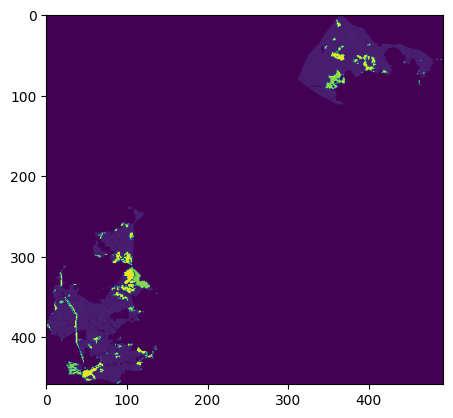

<Axes: >

In [56]:
show(masked_landcover_data)

In [57]:
legend_df = pd.read_csv(RAW_DATA_DIR / "landcover" / "legend_processed.csv")
column_name_map = legend_df.set_index("map_value")["class_b"].to_dict()

In [58]:
landcover_stats = zonal_stats(
    gdf,
    masked_landcover_data,
    affine=masked_transform,
    categorical=True,
    all_touched=True,
    category_map=column_name_map,
)

In [59]:
# make list of dics into df with keys as columns and values as rows
landcover_df = pd.DataFrame(landcover_stats)
landcover_df = landcover_df.fillna(0)

# add total count column
landcover_df["total_count"] = landcover_df.sum(axis=1)
landcover_df

,True desert,Semi-arid,Dense short vegetation,Open surface water,Cropland,Built-up,Tree cover,total_count
0,1409,649,3,72,1004,234,0.0,3371.0
1,503,84,2,123,420,5,1.0,1138.0


In [60]:
# divide by total count to get percentage
landcover_df_perc = (
    (landcover_df.div(landcover_df["total_count"], axis=0) * 100)
    .round(1)
    .drop(columns="total_count")
)
# add % to column names
landcover_df_perc.columns = [f"{col} %" for col in landcover_df_perc.columns]
landcover_df_perc

,True desert %,Semi-arid %,Dense short vegetation %,Open surface water %,Cropland %,Built-up %,Tree cover %
0,41.8,19.3,0.1,2.1,29.8,6.9,0.0
1,44.2,7.4,0.2,10.8,36.9,0.4,0.1


### Distance from roads

In [62]:
# fetch the nearby roads
# subset_gdf = gdf[gdf["source"] == "dhar"]
# dhar_bbox_shape = shapely.geometry.box(*subset_gdf.unary_union.bounds).buffer(0.1)
# G = ox.graph_from_polygon(
#     dhar_bbox_shape, network_type="all", retain_all=True, truncate_by_edge=True
# )
# dhar_roads_gdf = ox.graph_to_gdfs(G, nodes=False)


subset_gdf = gdf
sagar_bbox_shape = shapely.geometry.box(*subset_gdf.unary_union.bounds).buffer(0.1)
G = ox.graph_from_polygon(
    sagar_bbox_shape, network_type="all", retain_all=True, truncate_by_edge=True
)
sagar_roads_gdf = ox.graph_to_gdfs(G, nodes=False)

In [63]:
roads_gdf = sagar_roads_gdf #pd.concat([dhar_roads_gdf, sagar_roads_gdf], ignore_index=True)

<Axes: >

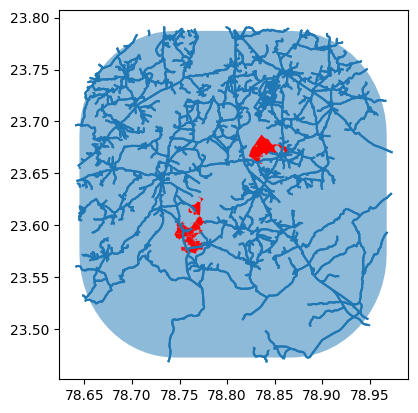

In [64]:
# plot
ax = gpd.GeoDataFrame(geometry=[sagar_bbox_shape]).plot(alpha=0.5) #dhar_bbox_shape, 
roads_gdf.plot(ax=ax)
subset_gdf.plot(ax=ax, color="red")

In [66]:
# these columns have some values that are lists and have issues saving to file later
roads_gdf["osmid"] = roads_gdf["osmid"].astype(str)
roads_gdf["highway"] = roads_gdf["highway"].astype(str)
roads_gdf["reversed"] = roads_gdf["reversed"].astype(bool)

save_shapefiles(
    roads_gdf,
    OUTPUT_DATA_DIR / "roads",
    "selected_roads",
    formats=["parquet", "kml"],
)

In [68]:
# sjoin nearest waterbody
gdf_with_road_stats = gpd.sjoin_nearest(
    gdf_stripped.to_crs("24378"),
    roads_gdf.to_crs("24378"),
    how="left",
    max_distance=None,
    distance_col="Distance to Nearest Road (meters)",
)

In [69]:
gdf_with_road_stats = (
    gdf_with_road_stats.sort_values("Distance to Nearest Road (meters)")
    .drop_duplicates(subset=["parcel_id"])
    .sort_index()
)

In [70]:
road_df = gdf_with_road_stats.drop(columns=["parcel_id", "geometry"])

In [71]:
road_df["Distance to Nearest Road (meters)"] = road_df["Distance to Nearest Road (meters)"].round(1)
road_df["Has Road Inside"] = road_df["Distance to Nearest Road (meters)"] == 0

In [72]:
road_df = road_df[
    [
        "Has Road Inside",
        "Distance to Nearest Road (meters)",
        "osmid",
        "ref",
        "highway",
        "oneway",
        "reversed",
        "length",
        "lanes",
        "name",
        "bridge",
    ]
]

In [73]:
# these columns have some values that are lists and have issues saving to file later
road_df["osmid"] = road_df["osmid"].astype(str)
road_df["highway"] = road_df["highway"].astype(str)

### Weather

In [75]:
import openmeteo_requests
import requests_cache
from retry_requests import retry

In [75]:
# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = -1)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

In [76]:
village_names_list = gdf["Source File Village Name"].unique()
lats = []
lons = []
for village_name in village_names_list:
    village_centroid = gdf[gdf["Source File Village Name"] == village_name].unary_union.centroid
    lat, lon = village_centroid.y, village_centroid.x
    lats.append(lat)
    lons.append(lon)

In [78]:
url = "https://archive-api.open-meteo.com/v1/archive"
params = {
    "latitude": lats,
    "longitude": lons,
    "start_date": "2024-01-01",
    "end_date": "2024-12-31",
    "hourly": ["temperature_2m", "relative_humidity_2m", "precipitation", "surface_pressure", "wind_speed_10m"],
}

# responses = openmeteo.weather_api(url, params=params)

In [78]:
# make a weather dataframe to add to
weather_df = pd.DataFrame(index=gdf.index)

In [ ]:
for i, response in enumerate(responses):
    village_name = village_names_list[i]
    print(f"Processing data for {village_name}")
    
    # Process hourly data. The order of variables needs to be the same as requested.
    hourly = response.Hourly()
    hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()
    hourly_relative_humidity_2m = hourly.Variables(1).ValuesAsNumpy()
    hourly_precipitation = hourly.Variables(2).ValuesAsNumpy()
    hourly_surface_pressure = hourly.Variables(3).ValuesAsNumpy()
    hourly_wind_speed_10m = hourly.Variables(4).ValuesAsNumpy()

    hourly_data = {"date": pd.date_range(
        start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
        end = pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
        freq = pd.Timedelta(seconds = hourly.Interval()),
        inclusive = "left"
    )}
    hourly_data["temperature_2m"] = hourly_temperature_2m
    hourly_data["relative_humidity_2m"] = hourly_relative_humidity_2m
    hourly_data["precipitation"] = hourly_precipitation
    hourly_data["surface_pressure"] = hourly_surface_pressure
    hourly_data["wind_speed_10m"] = hourly_wind_speed_10m
    # make the data into a df
    hourly_dataframe = pd.DataFrame(data = hourly_data)

    ## add the data to the weather_df
    mask = (gdf["Source File Village Name"] == village_name)

    # get temp avg min max
    weather_df.loc[mask, "2024 Average Temperature (C)"] = hourly_dataframe["temperature_2m"].mean()
    weather_df.loc[mask, "2024 Minimum Temperature (C)"] = hourly_dataframe["temperature_2m"].min()
    weather_df.loc[mask, "2024 Maximum Temperature (C)"] = hourly_dataframe["temperature_2m"].max()
    # get humidity avg min max
    weather_df.loc[mask, "2024 Average Relative Humidity (%)"] = hourly_dataframe["relative_humidity_2m"].mean()
    weather_df.loc[mask, "2024 Minimum Relative Humidity (%)"] = hourly_dataframe["relative_humidity_2m"].min()
    weather_df.loc[mask, "2024 Maximum Relative Humidity (%)"] = hourly_dataframe["relative_humidity_2m"].max()
    # get precipitation yealy sum
    weather_df.loc[mask, "2024 Total Precipitation (mm)"] = hourly_dataframe["precipitation"].sum()
    # get percipitation daily avg min max?
    # get pressure avg min max
    weather_df.loc[mask, "2024 Average Surface Pressure (hPa)"] = hourly_dataframe["surface_pressure"].mean()
    weather_df.loc[mask, "2024 Minimum Surface Pressure (hPa)"] = hourly_dataframe["surface_pressure"].min()
    weather_df.loc[mask, "2024 Maximum Surface Pressure (hPa)"] = hourly_dataframe["surface_pressure"].max()
    # get wind speed avg min max
    weather_df.loc[mask, "2024 Average Wind Speed (m/s)"] = hourly_dataframe["wind_speed_10m"].mean()
    weather_df.loc[mask, "2024 Minimum Wind Speed (m/s)"] = hourly_dataframe["wind_speed_10m"].min()
    weather_df.loc[mask, "2024 Maximum Wind Speed (m/s)"] = hourly_dataframe["wind_speed_10m"].max()

In [81]:
# weather_df.to_csv(OUTPUT_DATA_DIR / "weather.csv", index=True)

In [ ]:
weather_df = pd.read_csv(OUTPUT_DATA_DIR / "Final Export v1" / "weather_all.csv", index_col=0)
weather_df = weather_df.round(2)
weather_df

## Save to File

In [76]:
# merge all dataframes
final_gdf = gdf.merge(
    groundwater_df, left_index=True, right_index=True
).merge(
    waterbody_df, left_index=True, right_index=True
).merge(
    slope_df, left_index=True, right_index=True
).merge(
    landcover_df_perc, left_index=True, right_index=True
).merge(
    rooftop_df, left_index=True, right_index=True
).merge(
    road_df, left_index=True, right_index=True
).merge(
    solar_df, left_index=True, right_index=True
)#.merge(
#     weather_df, left_index=True, right_index=True
# )

In [77]:
final_gdf

,parcel_id_x,village_name_x,geometry,Parcel Area (m2),Stage of Groundwater Development Class,Groundwater Development Stage (%),Net Annual Groundwater Availability (ham),Annual Groundwater Draft Total (ham),Annual Groundwater Draft Irrigation (ham),Annual Groundwater Draft Domestic and Industrial Uses (ham),...,length,lanes,name,bridge,"Average Yearly Optimum Tilt Irradiation, GTI (kWh/m2)","Average Yearly Horizontal Irradiation, GHI (kWh/m2)","Average Yearly Potential PV Output, PVOUT (kWh/kWp)",Average Yearly Optimum Angle (deg),"Total Yearly Optimum Tilt Irradiation, GTI (kWh)","Total Yearly Horizontal Irradiation, GHI (kWh)"
1,0,khamkuwa,"MULTIPOLYGON (((78.75289 23.57730, 78.75302 23...",7.641329e+06,Safe,59.379,10136.47,6018.94,5749.6,269.34,...,32.458,NaN,NaN,NaN,2081,1906,1621,26,380968,348958
1,0,khamkuwa,"MULTIPOLYGON (((78.75289 23.57730, 78.75302 23...",7.641329e+06,Safe,59.379,10136.47,6018.94,5749.6,269.34,...,32.458,NaN,NaN,NaN,2081,1906,1621,26,380968,348958
1,0,khamkuwa,"MULTIPOLYGON (((78.75289 23.57730, 78.75302 23...",7.641329e+06,Safe,59.379,10136.47,6018.94,5749.6,269.34,...,32.458,NaN,NaN,NaN,2081,1906,1621,26,380968,348958


In [78]:
export_folderpath = OUTPUT_DATA_DIR / "Sagar"

In [79]:
# save variable list
var_df = final_gdf.drop(columns="geometry").transpose()
var_df = pd.DataFrame({"type": final_gdf.dtypes}, index=var_df.index)
var_df.to_csv(export_folderpath / "variable_list.csv")

In [80]:
# save all data
save_shapefiles(
    final_gdf.to_crs(epsg=4326),
    export_folderpath,
    "sagar_parcels_with_stats",
    formats=["parquet", "kml", "csv"],
)